# Momentum gestito per il rischio: risultati

La strategia è il WML (*winners minus losers*): si comprano i titoli del decile con il rendimento passato più alto (vincenti) e si vendono allo scoperto quelli del decile più basso (perdenti). Nella versione gestita il WML è moltiplicato ogni mese per un peso che dipende dalla volatilità prevista. Tutti i termini sono spiegati nel glossario del README (sezione 11).

Questo notebook rilegge i risultati del repository con le stesse funzioni degli script (`src/risk_managed_momentum`). Non sceglie niente di nuovo: il test 2012-2026 è stato eseguito una volta con `scripts/04_test_fuori_campione.py` e il suo esito è in `docs/esito_test.txt`.

Servono gli otto zip di French in `data/raw` (vedi `scripts/00_scarica_dati.py`).

In [1]:
import sys
from pathlib import Path

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RADICE / "src"))

import pandas as pd
from IPython.display import Image, display

from risk_managed_momentum import configurazione as cfg
from risk_managed_momentum import dati, esame, grafici, misure, serie

pd.set_option("display.precision", 3)
OUT = RADICE / "output"
OUT.mkdir(exist_ok=True)
tabella, pesi = serie.costruisci(dati.carica())

## 1. La regola in una riga

Peso del mese t = 12% / volatilità annua prevista, con la volatilità stimata dai 126 rendimenti giornalieri del WML fino alla fine del mese t-1. Quando il momentum è agitato il peso scende, quando è calmo sale (senza tetto).

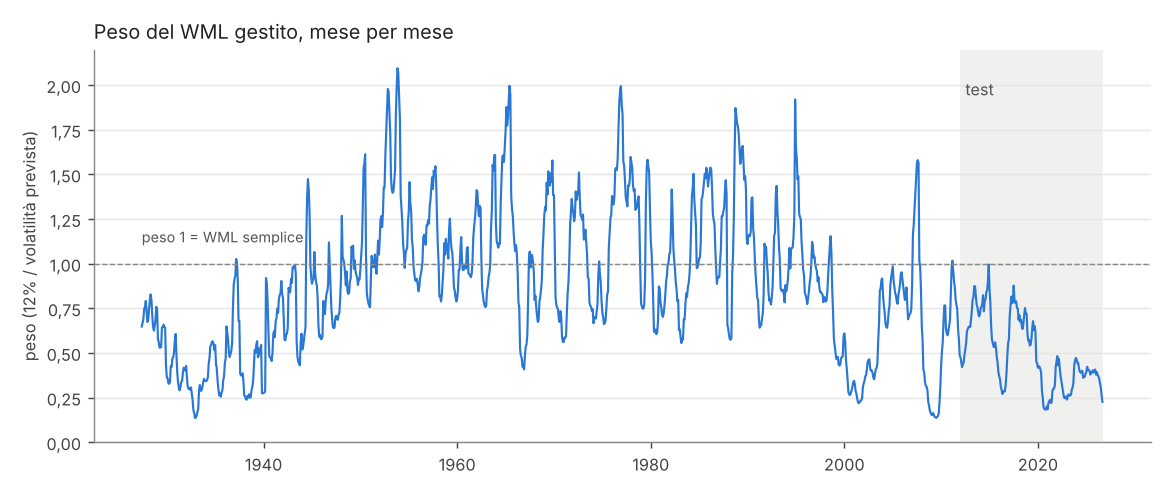

In [2]:
grafici.peso(pesi["wml"].dropna(), cfg.TEST_INIZIO, OUT / "peso_nel_tempo.png")
display(Image(filename=OUT / "peso_nel_tempo.png"))

## 2. Replica del paper (1927-2011)

Serve a controllare il codice: gli Sharpe devono tornare entro ±0,10 da 0,53 e 0,97.

In [3]:
replica = serie.finestra(tabella, None, "2011-12-31", ["wml", "wml_gestita"])
print(esame.formatta(misure.tabella({esame.NOMI[c]: replica[c] for c in replica.columns})))

              mesi   media volatilita sharpe asimmetria curtosi mese_peggiore mese_migliore drawdown
WML semplice  1016  14.86%     27.42%   0.54      -2.38   17.95       -77.66%        26.24%  -95.56%
WML gestito   1016  16.69%     16.77%   1.00      -0.36    2.00       -24.16%        21.71%  -43.83%


## 3. Test fuori campione (gennaio 2012 - agosto 2026)

Stesse regole, nessun parametro della strategia scelto da me. Il verdetto segue `docs/criteri_del_verdetto.md`.

In [4]:
righe, risultati = esame.analisi(tabella, pesi, cfg.TEST_INIZIO, cfg.TEST_FINE, cfg.SOTTOPERIODI,
                                 cfg.BOOTSTRAP, cfg.RITARDI_NEWEY_WEST)
v = risultati["verdetto"]
migliora = ", ".join(f"{k.replace('_', ' ')} {'migliora' if ok else 'non migliora'}" for k, ok in v["rischio"].items())
print("Ipotesi 1 (rischio):", "confermata" if v["ipotesi_1"] else "non confermata", f"({migliora})")
d = v["differenza"]
print(f"Ipotesi 2 (Sharpe): {v['ipotesi_2']}, differenza {d['stima']:+.3f}, IC95 [{d['basso']:+.3f}; {d['alto']:+.3f}]")

Ipotesi 1 (rischio): confermata (drawdown migliora, mese peggiore migliora, curtosi migliora)
Ipotesi 2 (Sharpe): evidenza di miglioramento, differenza +0.177, IC95 [+0.003; +0.333]


In [5]:
x = risultati["x"]
print(esame.formatta(misure.tabella({esame.NOMI[c]: x[c] for c in esame.NOMI})))

                       mesi   media volatilita sharpe asimmetria curtosi mese_peggiore mese_migliore drawdown
WML semplice            176   5.70%     28.89%   0.20      -0.68    2.10       -32.08%        25.17%  -64.77%
WML gestito             176   4.58%     12.22%   0.37      -0.00    1.05       -12.52%        11.28%  -23.03%
Mom di French           176   2.40%     13.28%   0.18      -0.72    2.26       -16.21%        10.04%  -25.38%
Mom gestito             176   4.36%     11.35%   0.38       0.02    0.77        -9.71%        11.10%  -18.56%
Vincenti solo lunghi    176  17.81%     21.48%   0.83       0.50    2.91       -15.81%        31.42%  -31.28%
Vincenti gestiti        176   9.31%     11.07%   0.84       0.20    1.78       -10.82%        13.36%  -14.04%
Mercato                 176  13.57%     14.48%   0.94      -0.39    0.97       -13.37%        13.60%  -25.28%
Mercato + WML gestito   176  18.15%     16.39%   1.11       0.10    0.80       -12.49%        18.86%  -18.80%


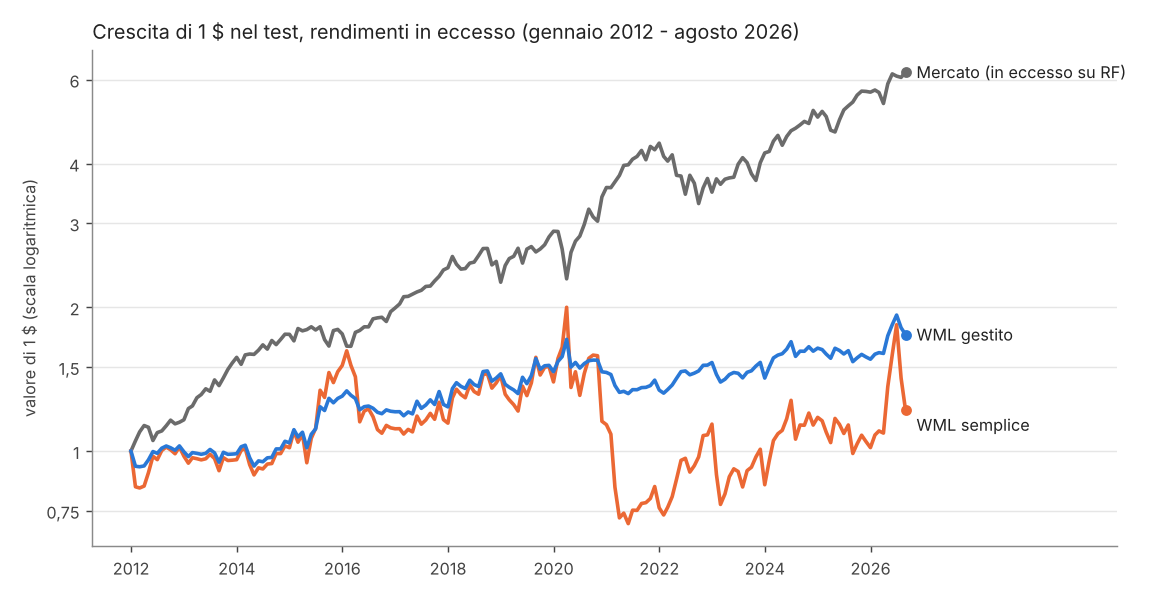

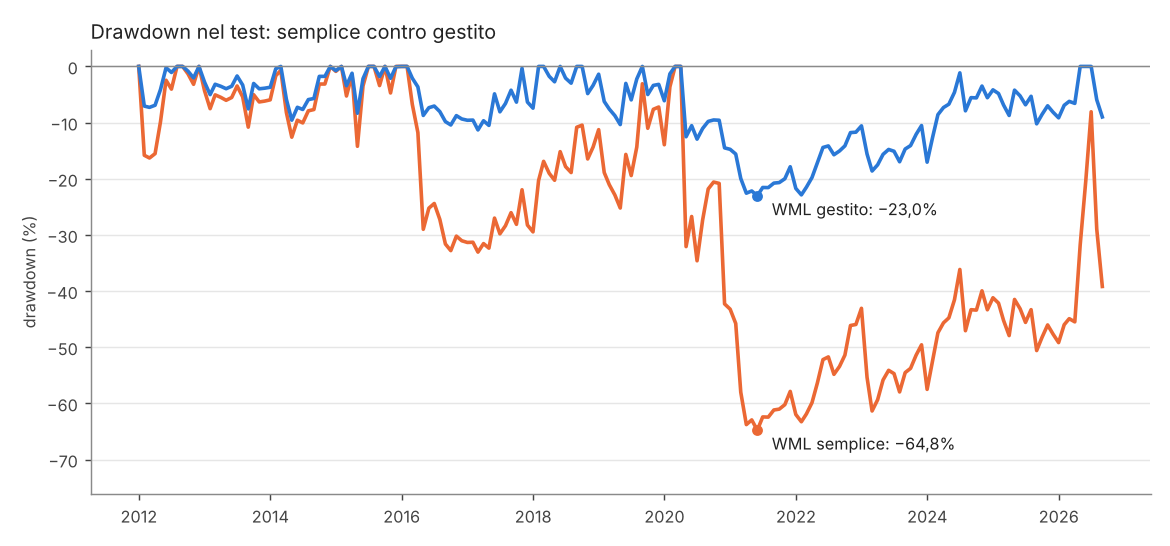

In [6]:
grafici.capitale(x, OUT / "capitale_test.png", "Crescita di 1 $ nel test, rendimenti in eccesso (gennaio 2012 - agosto 2026)")
grafici.drawdown(x, OUT / "drawdown_test.png", "Drawdown nel test: semplice contro gestito")
display(Image(filename=OUT / "capitale_test.png"))
display(Image(filename=OUT / "drawdown_test.png"))

## 4. Dove nasce il miglioramento

I mesi peggiori del momentum semplice arrivano quando la volatilità prevista è già alta, quindi il peso è già basso. In quattro casi su cinque il mercato rimbalza e i titoli perdenti (la gamba corta) salgono molto più dei vincenti; a luglio 2026 invece crollano i vincenti.

Un confronto più severo: il semplice ridotto con una costante alla stessa volatilità del gestito (scelta a posteriori). Così si separa il "quanto" rischio dal "quando".

In [7]:
peggiori = x["wml"].nsmallest(5).index
decili = dati.carica().decili_m
crolli = pd.DataFrame({"semplice": x.loc[peggiori, "wml"], "gestito": x.loc[peggiori, "wml_gestita"],
                       "mercato": x.loc[peggiori, "mercato"], "vincenti": decili.loc[peggiori, dati.VINCENTI],
                       "perdenti": decili.loc[peggiori, dati.PERDENTI]})
crolli = crolli.map(lambda v: f"{100 * v:.2f}%")
crolli.insert(1, "peso", risultati["pesi"].loc[peggiori, "wml"].round(2))
crolli.index = crolli.index.strftime("%Y-%m")
print("Rendimenti mensili (mercato in eccesso su RF; vincenti e perdenti non in eccesso)")
print(crolli.to_string())
k = x["wml_gestita"].std() / x["wml"].std()
print()
print(esame.formatta(misure.tabella({"WML semplice": x["wml"], f"WML semplice x {k:.3f}": k * x["wml"],
                                     "WML gestito": x["wml_gestita"]})))

Rendimenti mensili (mercato in eccesso su RF; vincenti e perdenti non in eccesso)
        semplice  peso  gestito mercato vincenti perdenti
data                                                     
2020-04  -32.08%  0.39  -12.52%  13.60%   14.67%   46.75%
2020-11  -27.10%  0.20   -5.44%  12.45%   10.38%   37.48%
2026-07  -22.71%  0.26   -5.93%  -0.61%  -15.41%    7.30%
2021-02  -22.57%  0.23   -5.16%   2.81%   -2.78%   19.79%
2023-01  -21.58%  0.26   -5.59%   6.61%    0.52%   22.10%

                      mesi  media volatilita sharpe asimmetria curtosi mese_peggiore mese_migliore drawdown
WML semplice           176  5.70%     28.89%   0.20      -0.68    2.10       -32.08%        25.17%  -64.77%
WML semplice x 0.423   176  2.41%     12.22%   0.20      -0.68    2.10       -13.57%        10.65%  -32.71%
WML gestito            176  4.58%     12.22%   0.37      -0.00    1.05       -12.52%        11.28%  -23.03%


## 5. Sottoperiodi e costi

Il miglioramento dello Sharpe viene dal 2016-2026; nel 2012-2015 le due versioni si equivalgono. Con i costi ipotizzati la differenza resta positiva ma l'intervallo include lo zero, e nello scenario alto il lungo-corto non rende.

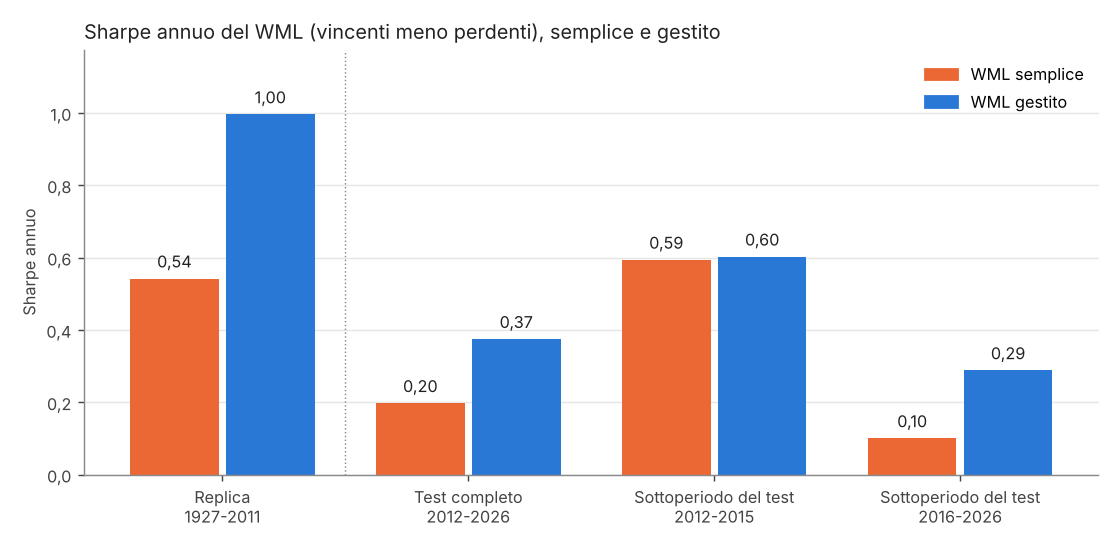

Sharpe netti per scenario di costo
                      lordo  medio  alto
WML semplice           0.20   0.04 -0.11
WML gestito            0.37   0.19 -0.00
Vincenti solo lunghi   0.83   0.74  0.64
Vincenti gestiti       0.84   0.73  0.63


In [8]:
valori = {
    "Replica\n1927-2011": {n: misure.sharpe(replica[n]) for n in ("wml", "wml_gestita")},
    "Test completo\n2012-2026": {n: misure.sharpe(x[n]) for n in ("wml", "wml_gestita")},
    **{f"Sottoperiodo del test\n{a[:4]}-{b[:4]}": {n: misure.sharpe(x.loc[a:b, n]) for n in ("wml", "wml_gestita")}
       for a, b in cfg.SOTTOPERIODI},
}
grafici.sharpe_periodi(valori, OUT / "sharpe_per_periodo.png")
display(Image(filename=OUT / "sharpe_per_periodo.png"))
print("Sharpe netti per scenario di costo")
print(pd.DataFrame({scen: {esame.NOMI[k]: misure.sharpe(s) for k, s in n.items()}
                    for scen, n in risultati["netti"].items()}).round(2).to_string())

## 6. Conclusione

La gestione della volatilità riduce i crolli del momentum anche fuori campione: drawdown, mese peggiore e curtosi scendono. Lo Sharpe migliora (da 0,197 a 0,375), ma l'intervallo al 95% sfiora lo zero e il vantaggio si concentra nel 2016-2026. Con i costi ipotizzati la differenza non è più distinguibile da zero, e il momentum in sé ha reso poco dopo il 2011. I dettagli e i limiti sono nel README e in `docs/metodo.md`.